In [1]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [2]:
IMAGE_SIZE =256
BATCH_SIZE=32
EPOCHS=50

In [3]:
dataset= tf.keras.preprocessing.image_dataset_from_directory(
    "Rice_Diseases",
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 400 files belonging to 5 classes.


In [4]:
class_names= dataset.class_names
class_names

['Bacterial Blight Disease',
 'Blast Disease',
 'Brown Spot Disease',
 'False Smut Disease',
 'Healthy']

In [5]:
len(dataset)

13

In [6]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())

(32, 256, 256, 3)
[1 4 4 2 0 4 4 4 3 3 4 0 1 4 4 2 0 0 0 2 3 4 4 4 2 4 1 0 2 1 4 4]


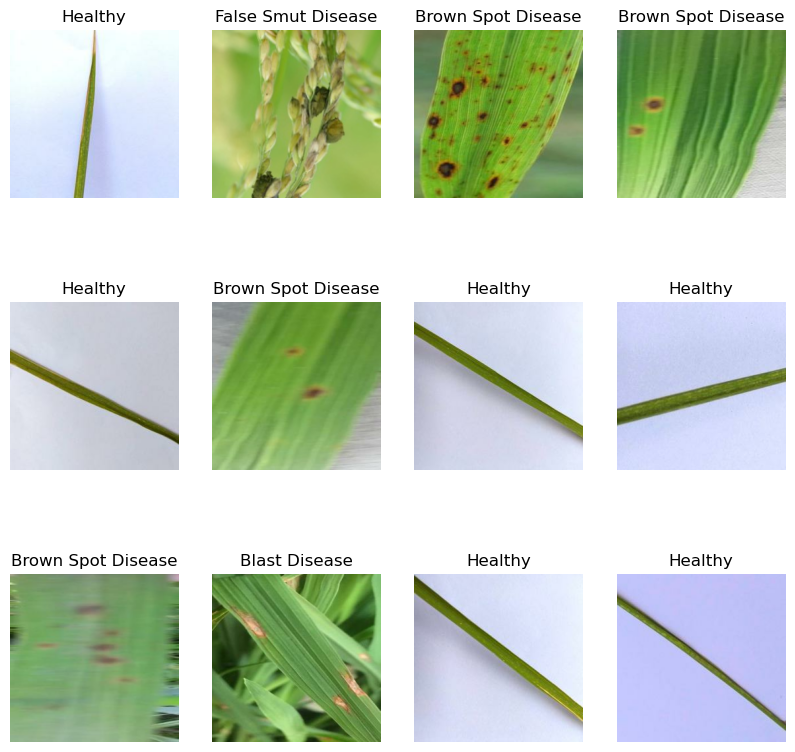

In [7]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [8]:
train_size=0.8
len(dataset)*train_size

10.4

In [9]:
train_ds=dataset.take(10)
len(train_ds)

10

In [10]:
test_ds=dataset.skip(10)
len(test_ds)

3

In [11]:
val_size=0.1
len(dataset)*val_size

1.3

In [12]:
val_ds=test_ds.take(1)
len(val_ds)

1

In [13]:
test_ds=test_ds.skip(len(val_ds))
len(test_ds)

2

In [14]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [15]:
from tensorflow.keras import layers

resize_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0 / 255)
])

In [16]:
data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [17]:
input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,3)
n_classes=5
model=models.Sequential([
    resize_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3), activation='relu',input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation='softmax'),
])
model.build(input_shape=input_shape)

C:\Users\Pramana\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (32, 12, 12, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 4, 4, 64)              │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 2, 2, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 256)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 64)                    │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 5)                     │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,877 (718.27 KB)

 Trainable params: 183,877 (718.27 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [20]:
m=model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5156 - loss: 1.2451 - val_accuracy: 0.4688 - val_loss: 1.0492
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6062 - loss: 0.8541 - val_accuracy: 0.4688 - val_loss: 0.9027
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5844 - loss: 0.8170 - val_accuracy: 0.5000 - val_loss: 0.9878
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5844 - loss: 0.9251 - val_accuracy: 0.6562 - val_loss: 0.8417
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6094 - loss: 0.8408 - val_accuracy: 0.7188 - val_loss: 0.7762
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6469 - loss: 0.7174 - val_accuracy: 0.6875 - val_loss: 0.7067
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6438 - loss: 0.6852 - val_accuracy: 0.5938 - val_loss: 0.7453
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6062 - loss: 0.6858 - val_accuracy: 0.6250 - val_loss:

In [21]:
scores=model.evaluate(test_ds)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 322ms/step - accuracy: 0.8333 - loss: 0.3023


In [22]:
print('Accuracy:',round(scores[1]*100,3),"%")
print('Loss:',round(scores[0]*100,3),"%")

Accuracy: 83.333 %
Loss: 30.231 %


In [23]:
m.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [24]:
accuracy=m.history['accuracy']
val_accuracy=m.history['val_accuracy']
loss=m.history['loss']
val_loss=m.history['val_loss']

Text(0.5, 1.0, 'training loss vs validation loss')

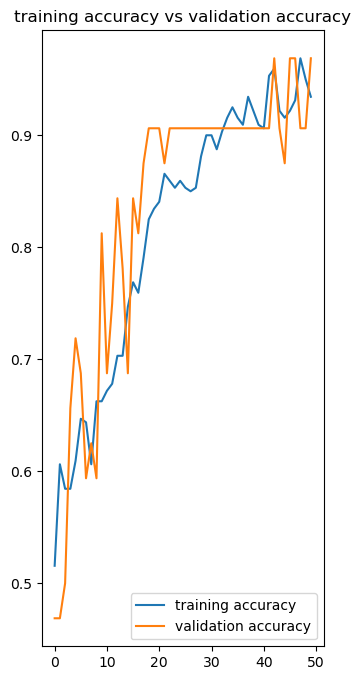

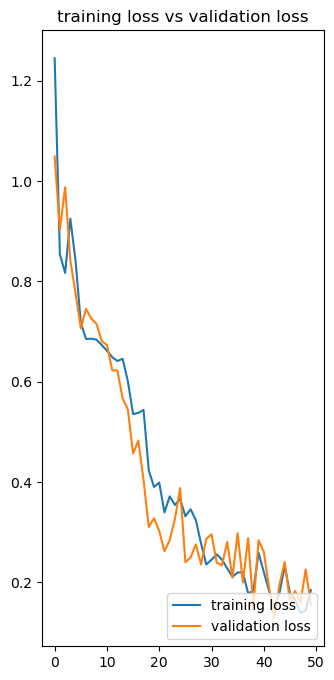

In [25]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), accuracy,label="training accuracy")
plt.plot(range(EPOCHS), val_accuracy,label="validation accuracy")
plt.legend(loc="lower right")
plt.title("training accuracy vs validation accuracy")

plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), loss,label="training loss")
plt.plot(range(EPOCHS), val_loss,label="validation loss")
plt.legend(loc="lower right")
plt.title("training loss vs validation loss")

Actual label: Blast Disease
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
Predicted label: Blast Disease


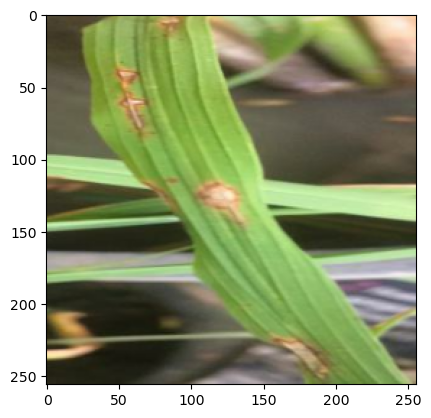

In [26]:
import numpy as np
for images_batch,labels_batch in test_ds.take(1):
    first_image=images_batch[0].numpy().astype('uint8')
    first_label=labels_batch[0].numpy()
    print('Actual label:',class_names[first_label])
    plt.imshow(first_image)
    batch_prediction=model.predict(images_batch)
    print('Predicted label:',class_names[np.argmax(batch_prediction[0])])
    

In [27]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0)
    predictions=model.predict(img_array)
    predicted_class=class_names[np.argmax(predictions[0])]
    confidence=round(100*np.max(predictions[0]),2)
    return predicted_class,confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


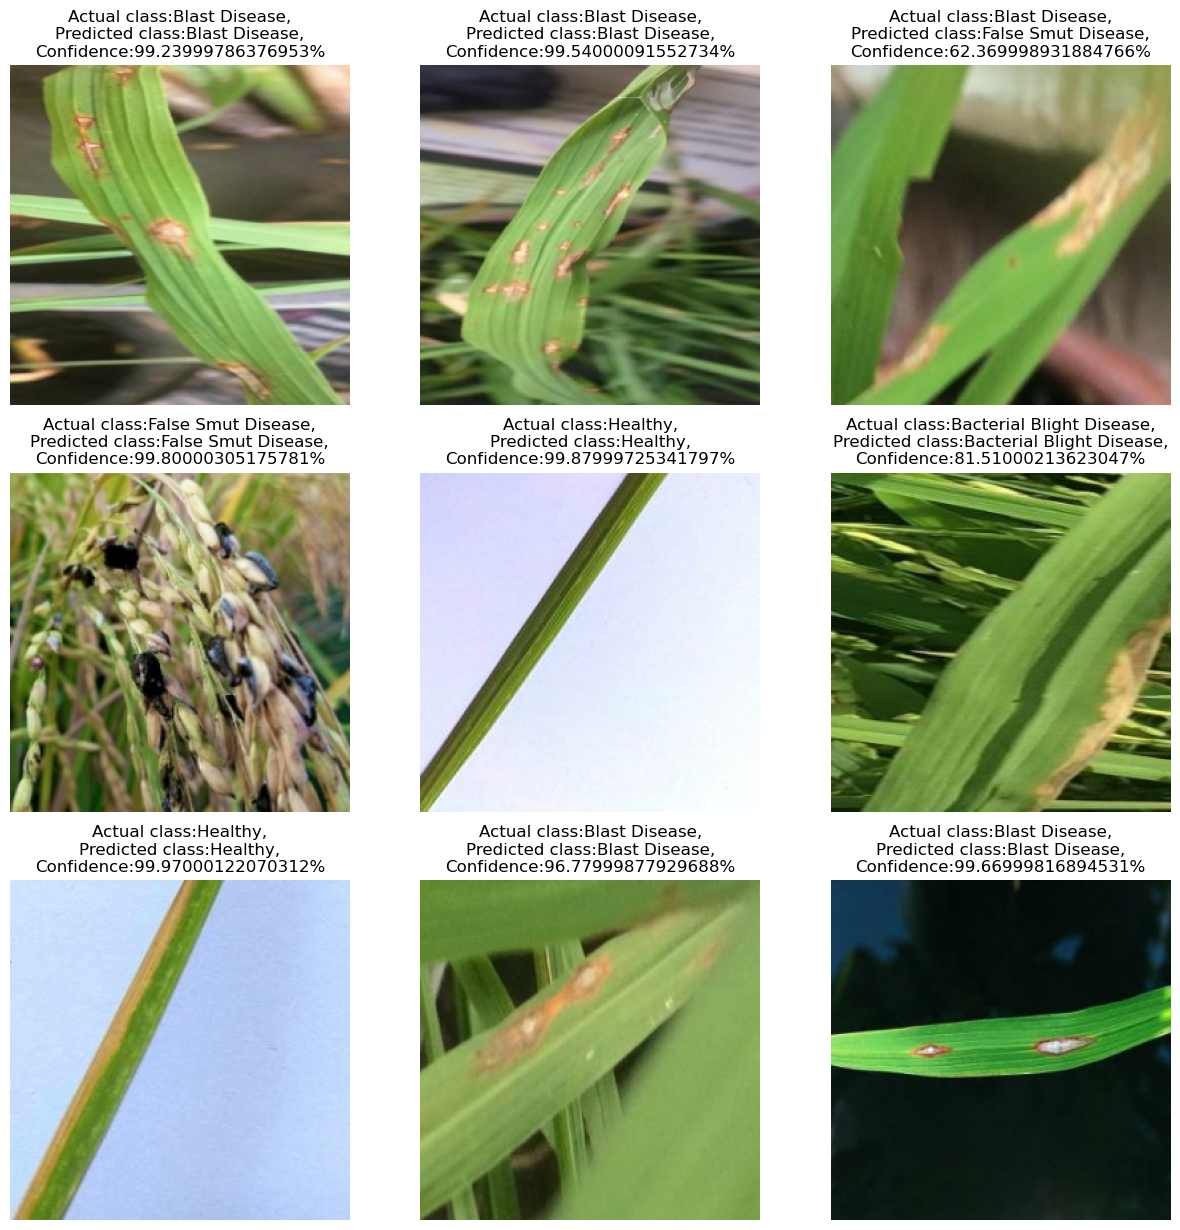

In [28]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        predicted_class,confidence=predict(model,images[i].numpy())
        actual_class=class_names[labels[i]]
        plt.title(f"Actual class:{actual_class},\nPredicted class:{predicted_class},\nConfidence:{confidence}%")
        plt.axis('off')

In [29]:
model.save('rice_crop_disease_using_cnn_model.h5')

In [36]:
import os
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# --- Configuration ---
# Path to your trained CNN model file
MODEL_PATH = 'rice_crop_disease_using_cnn_model.h5' 

# Path to the folder containing new images from the field you want to assess
FIELD_IMAGES_DIR = './RICE_DISEASES/Bacterial Blight Disease' 

# The image size your model expects (update these if your model uses a different size)
IMG_HEIGHT = 224 
IMG_WIDTH = 224

# Define your class indices based on how your model was trained
# Example: 0: Bacterial Blight, 1: Blast, 2: Brown Spot, 3: False Smut, 4: Healthy
HEALTHY_CLASS_INDEX = 4 

def calculate_disease_incidence(model_path, image_dir):
    # 1. Load the trained model
    print("Loading model...")
    model = load_model(model_path)
    
    total_plants = 0
    infected_plants = 0
    
    # Get all image files in the directory
    valid_extensions = ('.jpg', '.jpeg', '.png')
    image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(valid_extensions)]
    
    if not image_files:
        print("No images found in the specified directory.")
        return
        
    print(f"Assessing {len(image_files)} plants in the field...")

    # 2. Iterate through every image in the folder
    for img_name in image_files:
        img_path = os.path.join(image_dir, img_name)
        
        # Preprocess the image to match model requirements
        img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0 # Rescale pixel values if your model expects 0-1
        
        # 3. Make a prediction
        predictions = model.predict(img_array, verbose=0)
        predicted_class = np.argmax(predictions, axis=-1)[0]
        
        # 4. Tally the results
        total_plants += 1
        
        # If the predicted class is NOT the healthy class, it's infected
        if predicted_class != HEALTHY_CLASS_INDEX:
            infected_plants += 1
            
    # 5. Calculate final incidence percentage
    if total_plants > 0:
        incidence_percentage = (infected_plants / total_plants) * 100
        
        print("-" * 30)
        print("DISEASE INCIDENCE REPORT")
        print("-" * 30)
        print(f"Total Plants Assessed: {total_plants}")
        print(f"Infected Plants Found: {infected_plants}")
        print(f"Disease Incidence:     {incidence_percentage:.2f}%")
    else:
        print("Could not calculate incidence (divide by zero).")

# Run the function
if __name__ == "__main__":
    calculate_disease_incidence(MODEL_PATH, FIELD_IMAGES_DIR)

Loading model...


Assessing 50 plants in the field...
------------------------------
DISEASE INCIDENCE REPORT
------------------------------
Total Plants Assessed: 50
Infected Plants Found: 50
Disease Incidence:     100.00%


Disease Severity: 18.41%


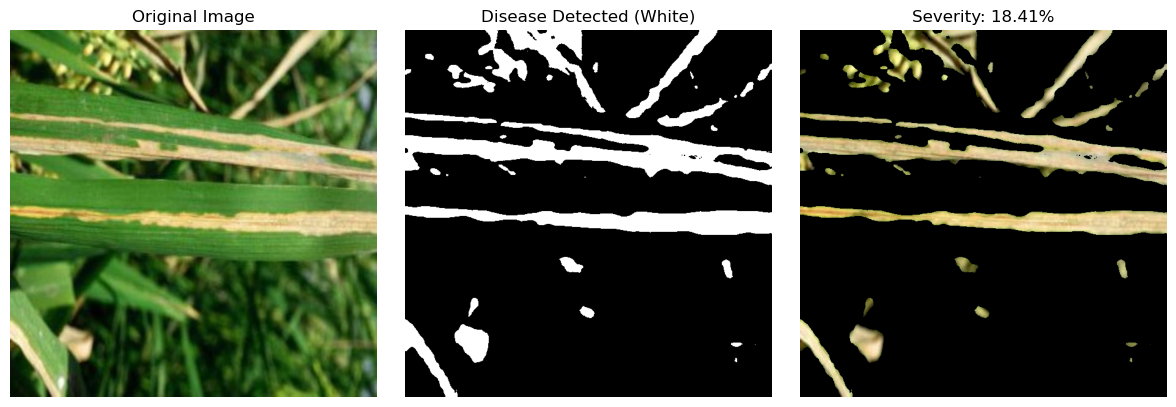

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def estimate_disease_severity(image_path):
    # 1. Load the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image at {image_path}")
        return
        
    # Resize for consistent processing speed and visualization
    img = cv2.resize(img, (600, 600))
    
    # 2. Convert to HSV color space 
    # HSV is much better for isolating colors regardless of shadows/lighting
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # 3. Define color ranges (Hue, Saturation, Value)
    # Healthy Green colors (Hue roughly 35 to 85)
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])

    # Diseased colors (Browns, Yellows, Oranges - Hue roughly 10 to 34)
    # Note: Dark brown/black spots might require an additional mask depending on the disease
    lower_disease = np.array([10, 40, 40])
    upper_disease = np.array([34, 255, 255])
    
    # 4. Create masks based on the color ranges
    # A mask acts like a stencil, keeping only the pixels that fall in our ranges
    healthy_mask = cv2.inRange(hsv_img, lower_green, upper_green)
    disease_mask = cv2.inRange(hsv_img, lower_disease, upper_disease)

    # 5. Count the pixels
    healthy_pixels = cv2.countNonZero(healthy_mask)
    disease_pixels = cv2.countNonZero(disease_mask)
    
    # The total area of the leaf is the healthy part + the diseased part
    # (This automatically ignores a white/black background!)
    total_leaf_pixels = healthy_pixels + disease_pixels

    # 6. Calculate Severity Percentage
    if total_leaf_pixels == 0:
        print("No leaf detected in the image based on the color ranges.")
        return 0
        
    severity_percentage = (disease_pixels / total_leaf_pixels) * 100
    print(f"Disease Severity: {severity_percentage:.2f}%")

    # 7. Visualization
    # Convert BGR to RGB so colors look correct in Matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Create an image showing ONLY the diseased parts for visual verification
    disease_highlight = cv2.bitwise_and(img_rgb, img_rgb, mask=disease_mask)

    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.title('Original Image')
    plt.imshow(img_rgb)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title('Disease Detected (White)')
    plt.imshow(disease_mask, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title(f'Severity: {severity_percentage:.2f}%')
    plt.imshow(disease_highlight)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return severity_percentage


# Replace 'test_leaf.jpg' with an actual path to a diseased leaf image from your dataset
if __name__ == "__main__":
    test_image = 'Rice_Diseases\Bacterial Blight Disease\BB (1).jpg' 
    severity = estimate_disease_severity(test_image)

In [39]:
hsv = cv2.cvtColor(first_image, cv2.COLOR_RGB2HSV)

lower_leaf = np.array([25,20,20])
upper_leaf = np.array([100,255,255])

leaf_mask = cv2.inRange(hsv, lower_leaf, upper_leaf)

total_leaf_pixels = cv2.countNonZero(leaf_mask)

lower_disease = np.array([5,40,40])
upper_disease = np.array([35,255,255])

disease_mask = cv2.inRange(hsv, lower_disease, upper_disease)

disease_mask = cv2.bitwise_and(disease_mask, leaf_mask)

diseased_pixels = cv2.countNonZero(disease_mask)

severity = (diseased_pixels / total_leaf_pixels) * 100

print("Total Leaf Pixels:", total_leaf_pixels)
print("Diseased Pixels:", diseased_pixels)
print("Severity:", severity)

Total Leaf Pixels: 46907
Diseased Pixels: 12843
Severity: 27.37970878546912


In [41]:
def calculate_yield_loss(disease_type, disease_severity_percent, potential_yield_tons_per_ha):

    loss_multipliers = {
        "Bacterial Blight Disease": 0.80,
        "Blast Disease": 1.00,
        "Brown Spot Disease": 0.50,
        "False Smut Disease": 0.40,
        "Healthy": 0.00
    }

    if disease_type not in loss_multipliers:
        print("Unknown Disease!")
        return None

    multiplier = loss_multipliers[disease_type]

    yield_loss_percent = disease_severity_percent * multiplier
    yield_loss_percent = min(yield_loss_percent, 100)

    estimated_loss_tons = potential_yield_tons_per_ha * (yield_loss_percent / 100)
    final_expected_yield = potential_yield_tons_per_ha - estimated_loss_tons

    print("=" * 60)
    print("          RICE YIELD LOSS ESTIMATION REPORT")
    print("=" * 60)
    print(f"Disease Detected       : {disease_type}")
    print(f"Disease Severity       : {disease_severity_percent:.2f}%")
    print(f"Healthy Yield          : {potential_yield_tons_per_ha:.2f} tons/ha")
    print("-" * 60)
    print(f"Yield Loss Percentage  : {yield_loss_percent:.2f}%")
    print(f"Estimated Yield Loss   : {estimated_loss_tons:.2f} tons/ha")
    print(f"Expected Final Yield   : {final_expected_yield:.2f} tons/ha")
    print("=" * 60)

    return {
        "Disease": disease_type,
        "Severity (%)": disease_severity_percent,
        "Yield Loss (%)": yield_loss_percent,
        "Yield Loss (tons/ha)": estimated_loss_tons,
        "Expected Yield (tons/ha)": final_expected_yield
    }


if __name__ == "__main__":

    cnn_prediction = predicted_class
    severity = (diseased_pixels / total_leaf_pixels) * 100

    healthy_yield = 6.5

    results = calculate_yield_loss(
        disease_type=cnn_prediction,
        disease_severity_percent=severity,
        potential_yield_tons_per_ha=healthy_yield
    )

    

          RICE YIELD LOSS ESTIMATION REPORT
Disease Detected       : Blast Disease
Disease Severity       : 27.38%
Healthy Yield          : 6.50 tons/ha
------------------------------------------------------------
Yield Loss Percentage  : 27.38%
Estimated Yield Loss   : 1.78 tons/ha
Expected Final Yield   : 4.72 tons/ha


In [42]:
treatments = {

    "Bacterial Blight Disease": {
        "Cause": "Bacteria (Xanthomonas oryzae pv. oryzae)",
        "Treatment": [
            "Use resistant rice varieties.",
            "Avoid excessive nitrogen fertilizer.",
            "Maintain proper field drainage.",
            "Remove severely infected plants.",
            "Copper-based bactericides may help reduce spread."
        ]
    },

    "Blast Disease": {
        "Cause": "Fungus (Magnaporthe oryzae)",
        "Treatment": [
            "Spray Tricyclazole (recommended).",
            "Avoid excess nitrogen fertilizer.",
            "Maintain proper spacing between plants.",
            "Remove infected leaves if possible.",
            "Use certified disease-free seeds."
        ]
    },

    "Brown Spot Disease": {
        "Cause": "Fungus (Bipolaris oryzae)",
        "Treatment": [
            "Apply Mancozeb or Propiconazole.",
            "Maintain balanced NPK fertilization.",
            "Improve irrigation management.",
            "Remove infected crop residues.",
            "Use healthy certified seeds."
        ]
    },

    "False Smut Disease": {
        "Cause": "Fungus (Ustilaginoidea virens)",
        "Treatment": [
            "Spray Propiconazole before flowering.",
            "Avoid excessive nitrogen fertilizer.",
            "Destroy infected panicles.",
            "Use disease-free seeds.",
            "Maintain proper field sanitation."
        ]
    },

    "Healthy": {
        "Cause": "No disease detected.",
        "Treatment": [
            "No treatment required.",
            "Continue proper irrigation.",
            "Maintain balanced fertilizer application.",
            "Regularly monitor crop health."
        ]
    }
}

In [43]:
print("Cause:")
print(treatments[predicted_class]["Cause"])

print("\nRecommended Treatment:")

for i, item in enumerate(treatments[predicted_class]["Treatment"], 1):
    print(f"{i}. {item}")

Cause:
Fungus (Magnaporthe oryzae)

Recommended Treatment:
1. Spray Tricyclazole (recommended).
2. Avoid excess nitrogen fertilizer.
3. Maintain proper spacing between plants.
4. Remove infected leaves if possible.
5. Use certified disease-free seeds.
